In [1]:
import sklearn

# [Windows에서 아래 코드를 실행하면 오류발생]:
# UnicodeDecodeError: 'cp949' codec can't decodeXXX
# model = LogisticRegression(max_iter=10000 )

# [해결방법]
# HTML 다이어그램 출력 기능을 끄고 텍스트로 표시
import platform
print(platform.system())
if platform.system()== 'Windows':
   sklearn.set_config(display='text')

Windows


In [2]:
import platform
import matplotlib.pyplot as plt

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

distance_matrix
Z:[[2.         3.         0.01624674 2.        ]
 [0.         1.         0.0162887  2.        ]
 [4.         5.         0.24024018 3.        ]
 [6.         7.         0.68548601 5.        ]]


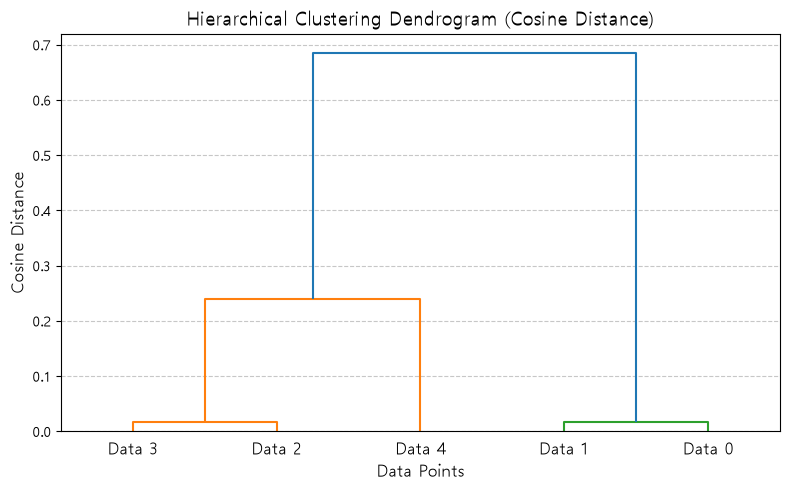

clusrers:[1 1 2 2 2]
--- 군집화 결과 ---
Data 0 -> Cluster 1
Data 1 -> Cluster 1
Data 2 -> Cluster 2
Data 3 -> Cluster 2
Data 4 -> Cluster 2


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist

# 1. 샘플 데이터 생성 (5개의 문서 또는 아이템의 특징 벡터)
# 코사인 거리는 방향성이 중요하므로 스파스(Sparse)하거나 고차원 특성 벡터에 유용합니다.
data = np.array(
    [
        [1.0, 0.9, 0.0, 0.0],  # 데이터 0 (A그룹 유사)
        [0.8, 1.0, 0.1, 0.0],  # 데이터 1 (A그룹 유사)
        [0.1, 0.0, 0.9, 1.0],  # 데이터 2 (B그룹 유사)
        [0.0, 0.2, 0.8, 0.9],  # 데이터 3 (B그룹 유사)
        [0.5, 0.5, 0.5, 0.5],  # 데이터 4 (중간 특성)
    ]
)

labels = ["Data 0", "Data 1", "Data 2", "Data 3", "Data 4"]

# 2. 코사인 거리 행렬(Distance Matrix) 계산
# metric='cosine'을 지정하여 코사인 거리를 계산합니다.
# 코사인 거리 = 1 - 코사인 유사도


# pdlist() : i<j 상삼각 행렬의 원소를 의미힌다.
distance_matrix = pdist(data, metric="cosine")
print(f'distance_matrix')

# 3. 계층적 군집화 수행 (Linkage 계산)
# 와드(Ward)법은 유클리드 거리만 지원하므로,
# 코사인 거리 사용 시 'average', 'complete', 'single' 등의 연결법을 사용합니다.
Z = linkage(distance_matrix, method="average")

print(f'Z:{Z}')
print('===============================================================')

# 4. 덴드로그램 시각화
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=labels, orientation="top", distance_sort="descending")

plt.title("Hierarchical Clustering Dendrogram (Cosine Distance)", fontsize=14)
plt.xlabel("Data Points", fontsize=12)
plt.ylabel("Cosine Distance", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 5. 특정 거리 임계값(Threshold) 또는 군집 수 기준으로 클러스터 라벨 추출
# 예: 코사인 거리가 0.5 이하인 것끼리 묶기
max_d = 0.5
clusters = fcluster(Z, criterion="distance", t=max_d)
print(f'clusrers:{clusters}')

print("--- 군집화 결과 ---")
for label, cluster_id in zip(labels, clusters):
  print(f"{label} -> Cluster {cluster_id}")

In [4]:
from scipy.spatial.distance import pdist, squareform

# 1D 10개 배열 -> 2D 5x5 행렬로 변환
full_matrix = squareform(distance_matrix)
print(full_matrix)

[[0.         0.0162887  0.94490337 0.89039255 0.29387056]
 [0.0162887  0.         0.90189949 0.82142407 0.260426  ]
 [0.94490337 0.90189949 0.         0.01624674 0.25875068]
 [0.89039255 0.82142407 0.01624674 0.         0.22172968]
 [0.29387056 0.260426   0.25875068 0.22172968 0.        ]]


## 와드 (ward) 사용법

distance_matrix=[0.24494897 1.85202592 1.71464282 0.9539392  1.7691806  1.60623784
 0.8660254  0.26457513 0.90553851 0.76811457]
Z:
[[0.         1.         0.24494897 2.        ]
 [2.         3.         0.26457513 2.        ]
 [4.         6.         0.95742711 3.        ]
 [5.         7.         2.25062954 5.        ]]


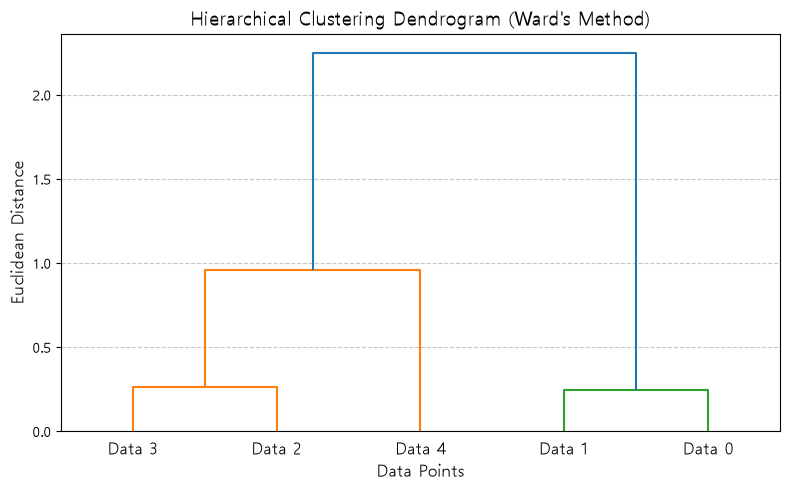

--- 군집화 결과 ---
Data 0 -> Cluster 1
Data 1 -> Cluster 1
Data 2 -> Cluster 2
Data 3 -> Cluster 2
Data 4 -> Cluster 3
=== 군집화 평가 지표 결과 ===
1. 실루엣 계수 (Silhouette Score)    : 0.5648
2. Calinski-Harabasz Index           : 46.0154
3. Davies-Bouldin Index              : 0.1555


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)


# 1. 샘플 데이터 생성
data = np.array(
[
[1.0, 0.9, 0.0, 0.0],  # 데이터 0 (A그룹 유사)
[0.8, 1.0, 0.1, 0.0],  # 데이터 1 (A그룹 유사)
[0.1, 0.0, 0.9, 1.0],  # 데이터 2 (B그룹 유사)
[0.0, 0.2, 0.8, 0.9],  # 데이터 3 (B그룹 유사)
[0.5, 0.5, 0.5, 0.5],  # 데이터 4 (중간 특성)
]
)

labels = ["Data 0", "Data 1", "Data 2", "Data 3", "Data 4"]

# 2. 코사인 특성 유지를 위한 L2 정규화 (각 행 벡터의 크기를 1로 맞춤)
distance_matrix = pdist(data, metric="euclidean")
print(f'distance_matrix={distance_matrix}')

# 3. 계층적 군집화 수행 (와드 연결법 method="ward")
Z = linkage(distance_matrix, method="ward")
print(f'Z:\n{Z}')

# 4. 덴드로그램 시각화
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=labels, orientation="top", distance_sort="descending")

plt.title("Hierarchical Clustering Dendrogram (Ward's Method)", fontsize=14)
plt.xlabel("Data Points", fontsize=12)
plt.ylabel("Euclidean Distance", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 5. 임계값(Threshold) 기준 클러스터 라벨 추출
max_d = 0.8
clusters = fcluster(Z, criterion="distance", t=max_d)

print("--- 군집화 결과 ---")
for label, cluster_id in zip(labels, clusters):
    print(f"{label} -> Cluster {cluster_id}")







# ==================================================
# 6. 군집화 평가 지표 계산 (Evaluation)
# ==================================================
# 평가 지표 산출을 위해서는 최소 2개 이상, 데이터 개수 미만의 군집이 필요합니다.
num_clusters = len(set(clusters))

if 1 < num_clusters < len(data):
  # (1) 실루엣 계수 (Silhouette Score) - 코사인 거리 지정 필수
  sil_score = silhouette_score(data, clusters, metric="euclidean")

  # (2) Calinski-Harabasz 지수 (Variance Ratio Criterion)
  ch_score = calinski_harabasz_score(data, clusters)

  # (3) Davies-Bouldin 지수
  db_score = davies_bouldin_score(data, clusters)

  print("=== 군집화 평가 지표 결과 ===")
  print(f"1. 실루엣 계수 (Silhouette Score)    : {sil_score:.4f}")
  print(f"2. Calinski-Harabasz Index           : {ch_score:.4f}")
  print(f"3. Davies-Bouldin Index              : {db_score:.4f}")
else:
  print(
      f"현재 형성된 군집 수({num_clusters}개)가 평가 기준을 충족하지 않습니다."
  )
  

## 코사인 거리 기반 계층적 군집화 코드에, 비지도 학습 평가 지표 3종 (실루엣 계수 , ...)

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

# 1. 샘플 데이터 생성
data = np.array(
    [
        [1.0, 0.9, 0.0, 0.0],  # 데이터 0 (A그룹 유사)
        [0.8, 1.0, 0.1, 0.0],  # 데이터 1 (A그룹 유사)
        [0.1, 0.0, 0.9, 1.0],  # 데이터 2 (B그룹 유사)
        [0.0, 0.2, 0.8, 0.9],  # 데이터 3 (B그룹 유사)
        [0.5, 0.5, 0.5, 0.5],  # 데이터 4 (중간 특성)
    ]
)
labels = ["Data 0", "Data 1", "Data 2", "Data 3", "Data 4"]

# 2. 코사인 거리 계산 및 계층적 군집화
distance_matrix = pdist(data, metric="cosine")
Z = linkage(distance_matrix, method="average")

# 3. 임계값(t=0.5) 기준으로 군집 라벨 추출
max_d = 0.5
clusters = fcluster(Z, criterion="distance", t=max_d)

print("--- 군집 할당 결과 ---")
for label, cluster_id in zip(labels, clusters):
  print(f"{label} -> Cluster {cluster_id}")
print("-" * 30)

# ==================================================
# 4. 군집화 평가 지표 계산 (Evaluation)
# ==================================================
# 평가 지표 산출을 위해서는 최소 2개 이상, 데이터 개수 미만의 군집이 필요합니다.
num_clusters = len(set(clusters))

if 1 < num_clusters < len(data):
  # (1) 실루엣 계수 (Silhouette Score) - 코사인 거리 지정 필수
  sil_score = silhouette_score(data, clusters, metric="cosine")

  # (2) Calinski-Harabasz 지수 (Variance Ratio Criterion)
  ch_score = calinski_harabasz_score(data, clusters)

  # (3) Davies-Bouldin 지수
  db_score = davies_bouldin_score(data, clusters)

  print("=== 군집화 평가 지표 결과 ===")
  print(f"1. 실루엣 계수 (Silhouette Score)    : {sil_score:.4f}")
  print(f"2. Calinski-Harabasz Index           : {ch_score:.4f}")
  print(f"3. Davies-Bouldin Index              : {db_score:.4f}")
else:
  print(
      f"현재 형성된 군집 수({num_clusters}개)가 평가 기준을 충족하지 않습니다."
  )

--- 군집 할당 결과 ---
Data 0 -> Cluster 1
Data 1 -> Cluster 1
Data 2 -> Cluster 2
Data 3 -> Cluster 2
Data 4 -> Cluster 2
------------------------------
=== 군집화 평가 지표 결과 ===
1. 실루엣 계수 (Silhouette Score)    : 0.7595
2. Calinski-Harabasz Index           : 14.5185
3. Davies-Bouldin Index              : 0.3486
